# Regressione Probabilistica tramite Processi Gaussiani (GPR)

In questa fase del progetto, l'obiettivo è modellare il **comportamento nominale** del motore aeronautico per definire un riferimento di "salute" della flotta. 
E' stata utilizzata la **Regressione tramite Processi Gaussiani (GPR)** per stimare la coppia target ($Trq_{target}$) in base alle condizioni operative.

Il valore aggiunto di questo approccio è la capacità di fornire non solo una stima puntuale, ma una **distribuzione di probabilità** che permette di calcolare il **Torque Margin** e la relativa incertezza.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

current_dir = Path.cwd()
while not (current_dir / "src").exists() and current_dir != current_dir.parent:
    current_dir = current_dir.parent
SRC_DIR = current_dir / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset import load_dataset
from regression.GPR.gpr_model import GPRModel
from regression.GPR.gpr_sampling import lhs_nearest_sampling
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target

plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [ ]:
ROOT_DIR = Path(os.getcwd()).parents[3]
SRC_PATH = ROOT_DIR / "src"
DATA_PATH = ROOT_DIR / "data" / "processed"
OUTPUT_PATH = ROOT_DIR / "output" / "GPR" / "model_target"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
OUTPUT_CSV = OUTPUT_PATH / "test_with_features_enriched.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model_500.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))


In [4]:
FEATURES=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TARGET_NAME = 'trq_target'

In [5]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)

In [ ]:
gpr_model = GPRModel(random_state=42)

# 2. Controllo esistenza modelli
if MODEL_FILE.exists() and SCALER_FILE.exists():
    print("Modello pre-addestrato trovato! Caricamento in corso...")
    try:
        gpr_model = joblib.load(MODEL_FILE)
        scaler = joblib.load(SCALER_FILE)
        print("SUCCESSO: Modello e Scaler caricati correttamente.")
        addestramento_necessario = False
    except Exception as e:
        print(f"Errore nel caricamento dei file: {e}")
        addestramento_necessario = True
else:
    print("Modello non trovato o incompleto. Avvio procedura di addestramento...")
    addestramento_necessario = True

# 3. Addestramento (solo se necessario)
if addestramento_necessario:
    # Campionamento LHS e Normalizzazione 
    X_train_scaled, y_train, scaler = lhs_nearest_sampling(
        train_df, FEATURES, TARGET_NAME, n_samples=5000
    )

    # Fit del Modello GPR
    print("Addestramento GPR in corso")
    gpr_model.fit(X_train_scaled, y_train)

    # Salvataggio fisico
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    try:
        joblib.dump(gpr_model, MODEL_FILE)
        joblib.dump(scaler, SCALER_FILE)
        print(f"SUCCESSO: Modello salvato in -> {MODEL_FILE}")
        print(f"SUCCESSO: Scaler salvato in -> {SCALER_FILE}")
    except Exception as e:
        print(f"ERRORE DURANTE IL SALVATAGGIO: {e}")

Modello non trovato o incompleto. Avvio procedura di addestramento...
Addestramento GPR in corso


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find 

SUCCESSO: Modello salvato in -> c:\Users\giada\OneDrive\Desktop\universita\magistrale\manutenzione preventiva\progetto\PHM_2024_Project\output\GPR\model_target\gpr_model_500.pkl
SUCCESSO: Scaler salvato in -> c:\Users\giada\OneDrive\Desktop\universita\magistrale\manutenzione preventiva\progetto\PHM_2024_Project\output\GPR\model_target\scaler_gpr.pkl


In [7]:
test_X = scaler.transform(test_df[FEATURES])
test_y=test_df[TARGET_NAME]

In [8]:
gpr_model.evaluate(test_X,test_y)

{'rmse': 0.034370593535285654,
 'mae': 0.012882414897329409,
 'r2': 0.9999941618428474}

Scoring del Margin

--- Analisi Volo ID: 100 ---
Margin Vero: -6.0470
Margin Predetto: -6.0477
Incertezza (std): 0.0781


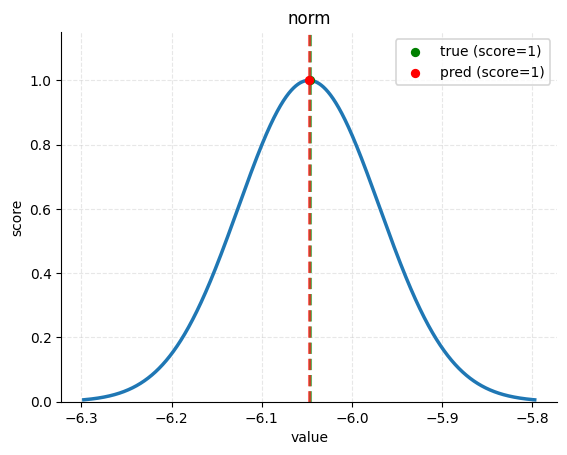

{'pdf_type': 'norm',
 'true_target': -6.047048375117548,
 'prediction': -6.0477458122564105,
 'score_true': 0.9999601235681878,
 'score_pred': 1.0000000050001,
 'x_range': (-6.297397093686979, -5.797397093686979)}

In [ ]:

# 2. Preparazione dei dati di test
# Usiamo lo scaler caricato dal file 
test_X = scaler.transform(test_df[FEATURES])
test_y_col = test_df[TARGET_NAME]

# 3. Selezione del volo 
idx = 100
flight_id = test_df.iloc[idx]['id'] if 'id' in test_df.columns else idx

# 4. Predizione Probabilistica
# row_X deve essere 2D per il modello
row_X = test_X[idx:idx+1]
mu, std = gpr_model.predict(row_X, return_std=True)

mu_target = float(mu[0])
std_target = float(std[0])

# 5. Recupero valori reali
trq_measured_real = float(test_df.iloc[idx]['trq_measured'])
# Prendiamo il valore reale del target solo per questa riga
trq_target_true = float(test_y_col.iloc[idx]) 

# 6. Calcolo Torque Margin (%) e Incertezza (Metodo Delta)
trq_margin_true = 100 * (trq_measured_real / trq_target_true - 1)
trq_margin_predetto = 100 * (trq_measured_real / mu_target - 1)

# Formula derivata: std_margin = |dM/dTrq_target| * std_target
std_margin = np.abs(-100 * trq_measured_real / (mu_target**2)) * std_target

# Log di verifica
print(f"--- Analisi Volo ID: {int(flight_id)} ---")
print(f"Margin Vero: {trq_margin_true:.4f}")
print(f"Margin Predetto: {trq_margin_predetto:.4f}")
print(f"Incertezza (std): {std_margin:.4f}")

# 7. Grafico della Distribuzione
pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}

plot_pdf_with_true_target(
    "norm",
    pdf_args=pdf_args,
    true_target=trq_margin_true,
    y_pred=trq_margin_predetto
)

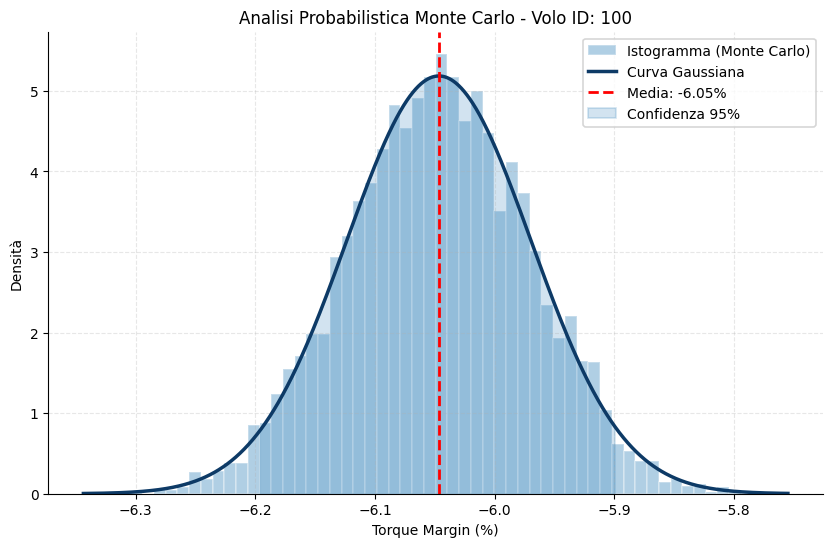

,Parametro,Valore
0,ID Volo,100
1,Media Margine (μ),-6.0465
2,Varianza (σ²),0.005921
3,Deviazione Standard (σ),0.0769
4,Intervallo Confidenza (95%),"[-6.20 , -5.90]"


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

idx = 100
flight_id = test_df.iloc[idx]['id'] if 'id' in test_df.columns else idx
test_row = test_X[idx:idx+1]

# B. Dati non scalati per la Matematica 
trq_measured_real = float(test_df.iloc[idx]['trq_measured'])

# Generazione campioni dal modello GPR
y_trq_samples = gpr_model.sample_y(test_row, n_sample=5000).flatten()

# trasfomrazione fisica del margin
margin_samples = 100 * (trq_measured_real / y_trq_samples - 1)

# 5. Calcolo Statistiche Empiriche 
mu_mc = np.mean(margin_samples)
var_mc = np.var(margin_samples)
std_mc = np.std(margin_samples)
ci_lower = np.percentile(margin_samples, 2.5)
ci_upper = np.percentile(margin_samples, 97.5)

# 6. Grafico 
plt.figure(figsize=(10, 6))
xmin = np.min(margin_samples)
xmax = np.max(margin_samples)
x_range = np.linspace(xmin, xmax, 1000)
plt.hist(margin_samples, bins=60, density=True, alpha=0.35, color='#1f77b4', 
         edgecolor='white', label='Istogramma (Monte Carlo)')
y_pdf = stats.norm.pdf(x_range, mu_mc, std_mc)
plt.plot(x_range, y_pdf, color='#0d3a66', lw=2.5, label='Curva Gaussiana')
plt.axvline(mu_mc, color='red', linestyle='--', lw=2, label=f'Media: {mu_mc:.2f}')
plt.fill_between(x_range, y_pdf, 
                 where=(x_range >= ci_lower) & (x_range <= ci_upper), 
                 color='#1f77b4', alpha=0.2, label='Confidenza 95%')
plt.title(f'Analisi Probabilistica Monte Carlo - Volo ID: {int(flight_id)}')
plt.xlabel('Torque Margin (%)')
plt.ylabel('Densità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Tabella Statistica Riassuntiva
stats_data = {
    "Parametro": [
        "ID Volo", 
        "Media Margine (μ)", 
        "Varianza (σ²)", 
        "Deviazione Standard (σ)", 
        "Intervallo Confidenza (95%)"
    ],
    "Valore": [
        int(flight_id), 
        f"{mu_mc:.4f}", 
        f"{var_mc:.6f}", 
        f"{std_mc:.4f}", 
        f"[{ci_lower:.2f} , {ci_upper:.2f}]"
    ]
}

display(pd.DataFrame(stats_data))